In [ ]:
#PACKAGE
import os
import pandas as pd
import re
import matplotlib.pyplot as plt

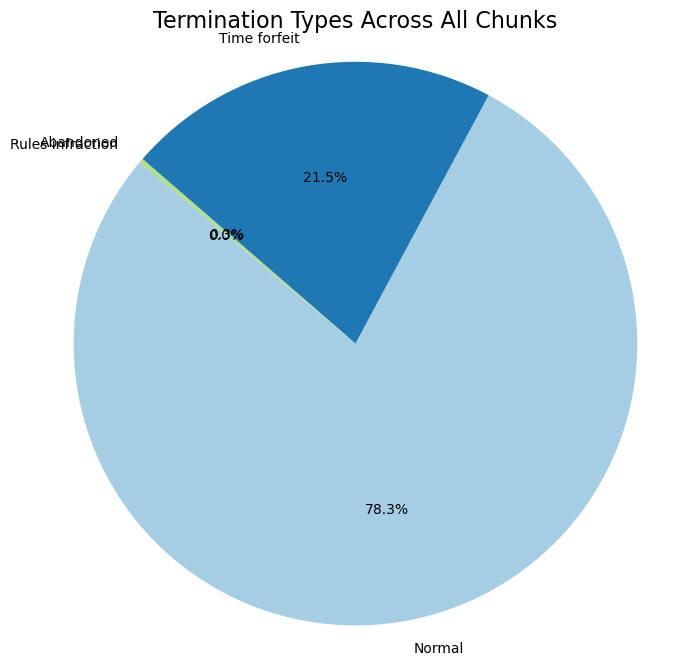

In [ ]:
# Initialize a dictionary to store the total counts for each termination type
termination_counts_total = {}

# Iterate through chunk_1.csv to chunk_300.csv
for i in range(1, 301):  # Since your chunks go from 1 to 300
    # Generate the filename
    filename = f'Filter_CSV/180+2/chunk_{i}.csv'
    
    # Read the CSV file into a DataFrame
    db = pd.read_csv(filename)
    
    # Count the number of games for each termination type in the current chunk
    termination_counts = db["Termination"].value_counts()
    
    # Add the counts from the current chunk to the total counts
    for termination_type, count in termination_counts.items():
        if termination_type in termination_counts_total:
            termination_counts_total[termination_type] += count
        else:
            termination_counts_total[termination_type] = count

# Convert the termination counts to a DataFrame for easier plotting
termination_counts_df = pd.DataFrame(list(termination_counts_total.items()), columns=["Termination", "Count"])

# Plot the pie chart
plt.figure(figsize=(8, 8))  # Adjust the size of the plot for better visibility
plt.pie(termination_counts_df["Count"], labels=termination_counts_df["Termination"], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Termination Types Across All Chunks", fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.

# Show the plot
plt.show()


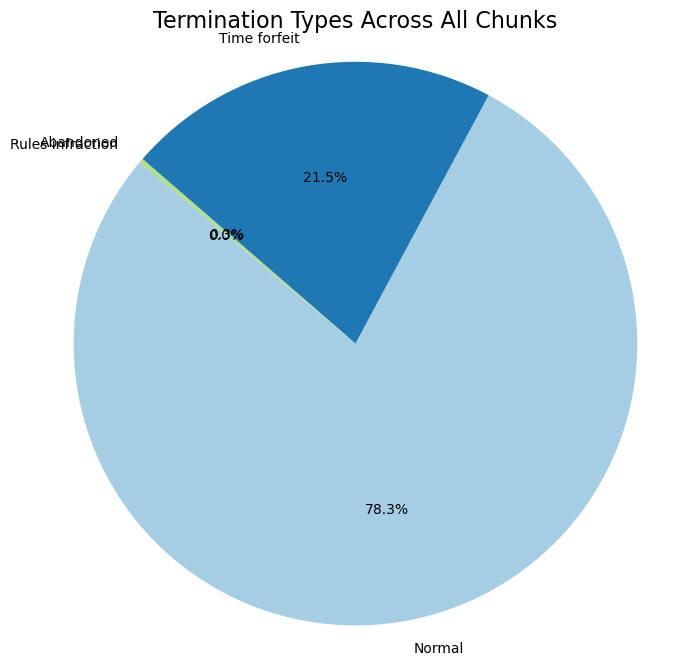

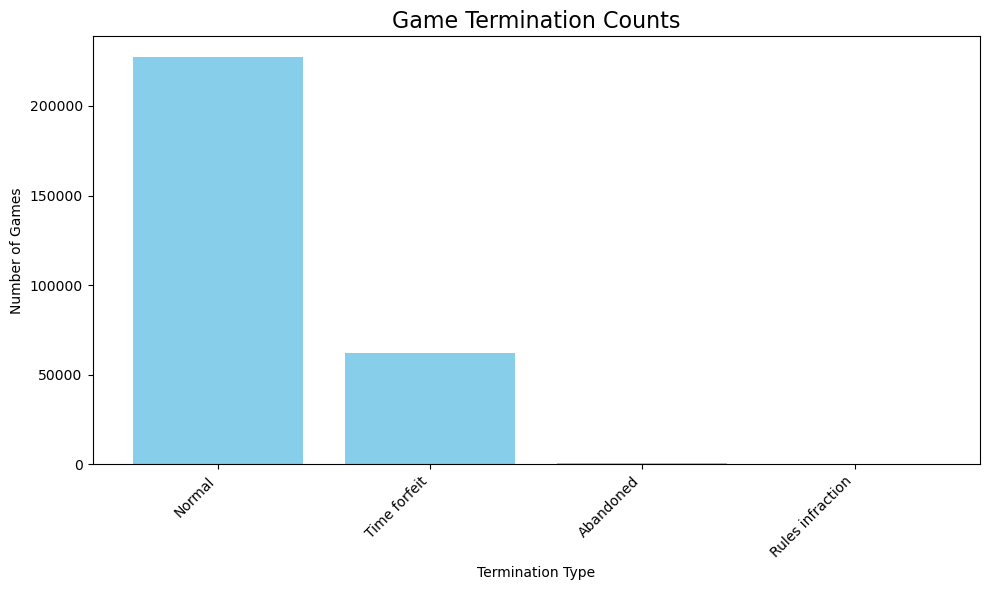

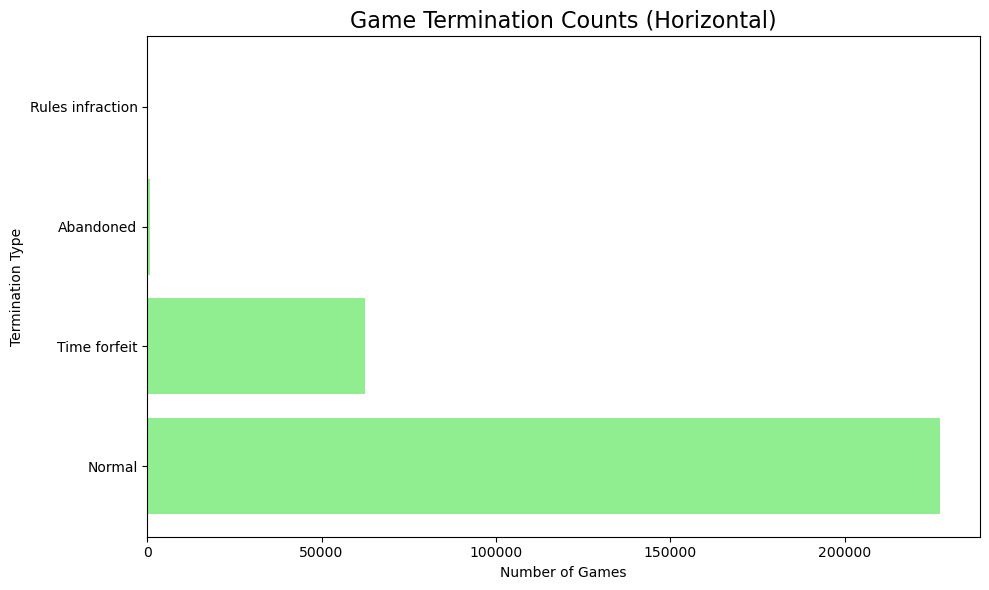

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize a dictionary to store the total counts for each termination type
termination_counts_total = {}

# Iterate through chunk_1.csv to chunk_300.csv
for i in range(1, 301):  # Since your chunks go from 1 to 300
    filename = f'Filter_CSV/180+2/chunk_{i}.csv'
    db = pd.read_csv(filename)
    termination_counts = db["Termination"].value_counts()
    
    for termination_type, count in termination_counts.items():
        termination_counts_total[termination_type] = termination_counts_total.get(termination_type, 0) + count

# Convert to DataFrame
termination_counts_df = pd.DataFrame(list(termination_counts_total.items()), columns=["Termination", "Count"])

# -------- PIE CHART --------
plt.figure(figsize=(8, 8))
plt.pie(termination_counts_df["Count"], labels=termination_counts_df["Termination"],
        autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Termination Types Across All Chunks", fontsize=16)
plt.axis('equal')
plt.show()

# -------- BAR CHART --------
plt.figure(figsize=(10, 6))
plt.bar(termination_counts_df["Termination"], termination_counts_df["Count"], color='skyblue')
plt.title("Game Termination Counts", fontsize=16)
plt.xlabel("Termination Type")
plt.ylabel("Number of Games")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -------- HORIZONTAL BAR CHART --------
plt.figure(figsize=(10, 6))
plt.barh(termination_counts_df["Termination"], termination_counts_df["Count"], color='lightgreen')
plt.title("Game Termination Counts (Horizontal)", fontsize=16)
plt.xlabel("Number of Games")
plt.ylabel("Termination Type")
plt.tight_layout()
plt.show()
